Device: cpu

── Loading data ──────────────────────────────────────────────
  Rows          : 15,168
  Unique patients: 3,788
  Date range    : 2005-09-29 → 2025-10-03

  Raw diagnosis counts:
    CN (Normal)    : 5,884
    MCI            : 6,325
    AD             : 2,918

── Applying Biological Irreversibility Filter ────────────────
  BIF corrected 527 biologically implausible reversals
  These were visits where diagnosis appeared to improve — impossible in AD

── Building 24-month Conversion Labels ──────────────────
  (Scanning every MCI patient's future — may take 1-2 minutes)

  Results:
  Total labeled MCI visits  : 4,967
  Unique MCI patients       : 1,308
  Converters  (label = 1)   : 781  (15.7%)
  Non-converters (label = 0): 4,186  (84.3%)

  Sanity check (expected: converters have LOWER MMSE, HIGHER TOTAL13):
               MMSCORE  TOTAL13    AGE
Non-converter    27.91    13.90  74.38
Converter        26.15    21.74  75.54

  MMSE  direction: ✅ PASS
  TOTAL13 direction: ✅

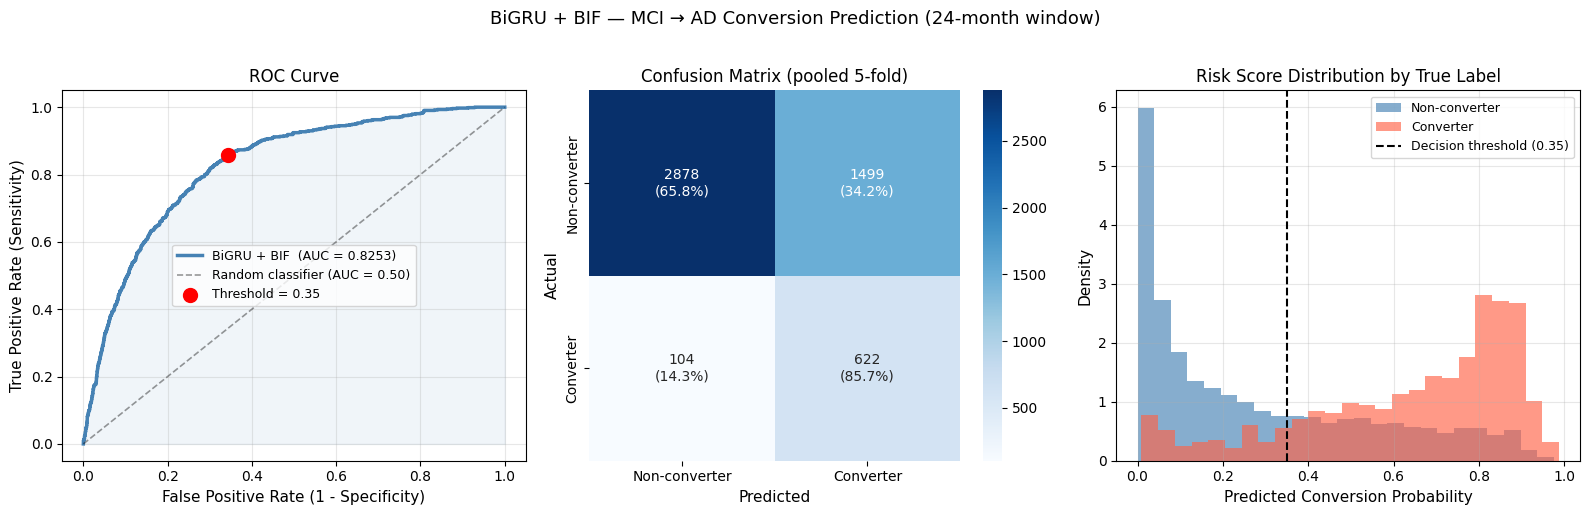

  Saved: bigru_mci_ad_results.png

── SHAP Feature Importance ───────────────────────────────────
  (Computing SHAP values — takes 3–8 minutes)


  0%|          | 0/100 [00:00<?, ?it/s]

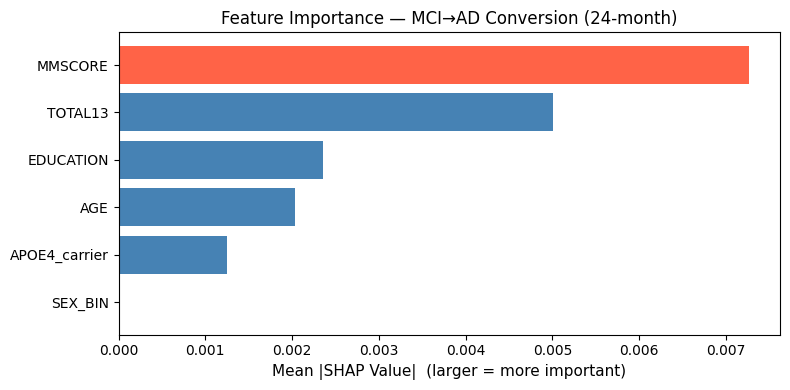

  Saved: shap_importance.png

  Feature ranking (most → least important):
    MMSCORE             ████████████████████  0.00726
    TOTAL13             █████████████  0.00501
    EDUCATION           ██████  0.00235
    AGE                 █████  0.00204
    APOE4_carrier       ███  0.00125
    SEX_BIN               0.00000

── Building Deployable Risk Scoring Function ─────────────────
  Model saved : bigru_ad_risk_model.pt
  Scaler saved: bigru_scaler.pkl

  ── Demo: High-Risk MCI Patient ──────────────────────────────
  Risk probability  : 88.3%
  Risk level        : HIGH RISK
  Decision          : Recommend expedited neurology referral and consider enrollment in early intervention or clinical trial.
  Visits used       : 3

  ── Demo: Low-Risk MCI Patient ───────────────────────────────
  Risk probability  : 22.4%
  Risk level        : LOW RISK
  Decision          : Maintain routine annual monitoring. Lifestyle counselling recommended.
  Visits used       : 3


█████████████████████

In [ ]:
# ============================================================================
#  MCI → AD CONVERSION RISK PREDICTION


!pip install shap --quiet

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    roc_auc_score, accuracy_score, f1_score,
    recall_score, precision_score,
    confusion_matrix, roc_curve
)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings, os
warnings.filterwarnings("ignore")


SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
import random
random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

FILE_PATH        ="/content/FINAL_CLEAN_FULL_with_demo_apoe_age_fixed (1).csv"
WINDOW_MONTHS    = 24      
FEATURES         = ["MMSCORE", "TOTAL13", "AGE",
                    "SEX_BIN", "EDUCATION", "APOE4_carrier"]
HIDDEN_SIZE      = 64        
DROPOUT          = 0.3
LEARNING_RATE    = 0.001
EPOCHS           = 60
BATCH_SIZE       = 32
N_FOLDS          = 5
RISK_THRESHOLD   = 0.35      




print("\n── Loading data ──────────────────────────────────────────────")
df_raw = pd.read_csv(FILE_PATH)
df_raw.columns = df_raw.columns.str.strip()

df_raw["EXAMDATE"] = pd.to_datetime(df_raw["EXAMDATE"], errors="coerce")

print(f"  Rows          : {len(df_raw):,}")
print(f"  Unique patients: {df_raw['RID'].nunique():,}")
print(f"  Date range    : {df_raw['EXAMDATE'].min().date()} → "
      f"{df_raw['EXAMDATE'].max().date()}")
print(f"\n  Raw diagnosis counts:")
diag_map = {1.0: "CN (Normal)", 2.0: "MCI", 3.0: "AD"}
for code, label in diag_map.items():
    n = (df_raw["DIAGNOSIS"] == code).sum()
    print(f"    {label:15s}: {n:,}")



print("\n── Applying Biological Irreversibility Filter ────────────────")

df = df_raw.copy()
df = df.sort_values(["RID", "EXAMDATE"]).reset_index(drop=True)

# Count reversals before fixing them (we report this number in the paper)
df["DIAG_RAW"] = df["DIAGNOSIS"].copy()
df["DIAGNOSIS"] = df.groupby("RID")["DIAGNOSIS"].cummax()

n_reversals = (df["DIAG_RAW"] != df["DIAGNOSIS"]).sum()
print(f"  BIF corrected {n_reversals:,} biologically implausible reversals")
print(f"  These were visits where diagnosis appeared to improve — impossible in AD")




print(f"\n── Building {WINDOW_MONTHS}-month Conversion Labels ──────────────────")
print("  (Scanning every MCI patient's future — may take 1-2 minutes)")

def build_conversion_labels(df_bif, window_months):
    records = []

    for rid, patient in df_bif.groupby("RID"):
        patient = patient.sort_values("EXAMDATE").reset_index(drop=True)


        mci_visits = patient[patient["DIAGNOSIS"] == 2.0]

        for _, visit in mci_visits.iterrows():
            t0         = visit["EXAMDATE"]           
            window_end = t0 + pd.DateOffset(months=window_months)

            
            future = patient[
                (patient["EXAMDATE"] > t0) &
                (patient["EXAMDATE"] <= window_end)
            ]

            if len(future) == 0:
               
                continue
            elif (future["DIAGNOSIS"] == 3.0).any():
                label = 1   
            else:
                label = 0   

            row = {
                "RID"          : rid,
                "EXAMDATE"     : t0,
                "CONVERTER"    : label,
            }
            for feat in FEATURES:
                row[feat] = visit.get(feat, np.nan)

            records.append(row)

    label_df = pd.DataFrame(records)
    return label_df


label_df = build_conversion_labels(df, WINDOW_MONTHS)


n_total     = len(label_df)
n_converters = label_df["CONVERTER"].sum()
n_non        = n_total - n_converters
conv_rate    = n_converters / n_total * 100

print(f"\n  Results:")
print(f"  Total labeled MCI visits  : {n_total:,}")
print(f"  Unique MCI patients       : {label_df['RID'].nunique():,}")
print(f"  Converters  (label = 1)   : {n_converters:,}  ({conv_rate:.1f}%)")
print(f"  Non-converters (label = 0): {n_non:,}  ({100-conv_rate:.1f}%)")


print(f"\n  Sanity check (expected: converters have LOWER MMSE, HIGHER TOTAL13):")
check = label_df.groupby("CONVERTER")[["MMSCORE","TOTAL13","AGE"]].mean().round(2)
check.index = ["Non-converter","Converter"]
print(check.to_string())

mmse_ok  = check.loc["Converter","MMSCORE"]  < check.loc["Non-converter","MMSCORE"]
total_ok = check.loc["Converter","TOTAL13"]  > check.loc["Non-converter","TOTAL13"]
print(f"\n  MMSE  direction: {'PASS' if mmse_ok  else ' CHECK LABEL LOGIC'}")
print(f"  TOTAL13 direction: {'PASS' if total_ok else 'CHECK LABEL LOGIC'}")




print("\n── Building Longitudinal Sequences ───────────────────────────")

def build_sequences(df_full, label_df, features):

    df_work = df_full.copy()
    for feat in features:
        if feat in df_work.columns:
            df_work[feat] = df_work[feat].fillna(df_work[feat].median())

    sequences, labels, pids = [], [], []

    for _, row in label_df.iterrows():
        rid  = row["RID"]
        t0   = row["EXAMDATE"]

        history = df_work[
            (df_work["RID"] == rid) &
            (df_work["EXAMDATE"] <= t0)
        ].sort_values("EXAMDATE")

        if len(history) == 0:
            continue

        feats_present = [f for f in features if f in history.columns]
        seq = history[feats_present].values.astype(np.float32)

        sequences.append(seq)
        labels.append(int(row["CONVERTER"]))
        pids.append(rid)


    max_len = max(s.shape[0] for s in sequences)
    n_feats = sequences[0].shape[1]

    X = np.zeros((len(sequences), max_len, n_feats), dtype=np.float32)
    for i, seq in enumerate(sequences):
        X[i, :len(seq), :] = seq

    return X, np.array(labels, dtype=np.float32), np.array(pids)


X, y, pids = build_sequences(df, label_df, FEATURES)

print(f"  Sequence array : {X.shape}  (patients × max_visits × features)")
print(f"  Labels         : {y.shape}  |  {y.mean()*100:.1f}% converters")
print(f"  Max seq length : {X.shape[1]} visits per patient")
print(f"  Features used  : {FEATURES}")




class ADConversionDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):  return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]


class BiGRU_ADRisk(nn.Module):
    """
    Bidirectional GRU that outputs a PROBABILITY of MCI→AD conversion.

    Input  : [batch_size, max_visits, n_features]
    Output : [batch_size]  — values between 0 and 1
                             0.0 = definitely will NOT convert
                             1.0 = definitely WILL convert
    """
    def __init__(self, n_features, hidden=64, dropout=0.3):
        super().__init__()

        self.bigru = nn.GRU(
            input_size    = n_features,
            hidden_size   = hidden,
            num_layers    = 1,
            batch_first   = True,
            bidirectional = True     
        )

        self.bn      = nn.BatchNorm1d(hidden * 2)
        self.dropout = nn.Dropout(dropout)

        self.fc      = nn.Linear(hidden * 2, 1)

    def forward(self, x):
        out, _  = self.bigru(x)        
        last    = out[:, -1, :]         
        last    = self.bn(last)         
        last    = self.dropout(last)    
        logit   = self.fc(last).squeeze(-1)
        return logit                    



_test = BiGRU_ADRisk(n_features=len(FEATURES))
_out  = _test(torch.zeros(4, X.shape[1], len(FEATURES)))
print(f"\n── Model ─────────────────────────────────────────────────────")
print(f"  Architecture  : Bidirectional GRU")
print(f"  Hidden units  : {HIDDEN_SIZE} per direction ({HIDDEN_SIZE*2} combined)")
print(f"  Input shape   : [batch, {X.shape[1]}, {len(FEATURES)}]")
print(f"  Output shape  : {list(_out.shape)}  ← one risk score per patient")
n_params = sum(p.numel() for p in _test.parameters() if p.requires_grad)
print(f"  Parameters    : {n_params:,}")
del _test, _out



print("\n── Training: 5-Fold Patient-Level Cross-Validation ───────────")

def run_one_fold(X_tr, y_tr, X_te, y_te):
    """
    Trains the BiGRU on one fold and returns evaluation metrics.
    The StandardScaler is fitted ONLY on training data and applied to test.
    """
    n_tr, seq_len, n_f = X_tr.shape


    sc        = StandardScaler()
    X_tr_s    = sc.fit_transform(X_tr.reshape(-1, n_f)).reshape(n_tr, seq_len, n_f)
    X_te_s    = sc.transform(X_te.reshape(-1, n_f)).reshape(len(X_te), seq_len, n_f)

    n_neg      = (y_tr == 0).sum()
    n_pos      = (y_tr == 1).sum()
    pos_weight = torch.tensor([n_neg / (n_pos + 1e-6)]).to(DEVICE)


    def seed_worker(worker_id):
        worker_seed = SEED + worker_id
        np.random.seed(worker_seed)
        random.seed(worker_seed)

    g = torch.Generator()
    g.manual_seed(SEED)
    tr_dl = DataLoader(ADConversionDataset(X_tr_s, y_tr),
                       batch_size=BATCH_SIZE, shuffle=True, drop_last=True,
                       worker_init_fn=seed_worker, generator=g)
    te_dl = DataLoader(ADConversionDataset(X_te_s, y_te),
                       batch_size=BATCH_SIZE, shuffle=False)

    torch.manual_seed(SEED)
    np.random.seed(SEED)
    random.seed(SEED)

    model     = BiGRU_ADRisk(n_features=n_f, hidden=HIDDEN_SIZE,
                             dropout=DROPOUT).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    opt       = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE,
                                 weight_decay=1e-4)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, patience=5, factor=0.5
    )

    for epoch in range(EPOCHS):
        model.train()
        epoch_loss = 0
        for xb, yb in tr_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            epoch_loss += loss.item()
        scheduler.step(epoch_loss)


    model.eval()
    all_probs, all_preds, all_true = [], [], []

    with torch.no_grad():
        for xb, yb in te_dl:
            xb       = xb.to(DEVICE)
            probs    = torch.sigmoid(model(xb)).cpu().numpy()
            preds    = (probs >= RISK_THRESHOLD).astype(int)
            all_probs.extend(probs.tolist())
            all_preds.extend(preds.tolist())
            all_true.extend(yb.numpy().astype(int).tolist())

    return {
        "accuracy"   : accuracy_score(all_true, all_preds),
        "auc"        : roc_auc_score(all_true, all_probs),
        "sensitivity": recall_score(all_true, all_preds, pos_label=1, zero_division=0),
        "specificity": recall_score(all_true, all_preds, pos_label=0, zero_division=0),
        "f1"         : f1_score(all_true, all_preds, zero_division=0),
        "precision"  : precision_score(all_true, all_preds, zero_division=0),
        "probs"      : all_probs,
        "labels"     : all_true,
    }, sc, model  


gss          = GroupShuffleSplit(n_splits=N_FOLDS, test_size=0.2,
                                 random_state=SEED)
fold_metrics = []
all_probs_cv, all_labels_cv = [], []
best_auc, best_scaler, best_model = 0, None, None

for fold_i, (tr_idx, te_idx) in enumerate(gss.split(X, y, groups=pids)):
    metrics, scaler_fold, model_fold = run_one_fold(
        X[tr_idx], y[tr_idx], X[te_idx], y[te_idx]
    )
    fold_metrics.append(metrics)
    all_probs_cv.extend(metrics["probs"])
    all_labels_cv.extend(metrics["labels"])

    print(f"  Fold {fold_i+1}:  "
          f"Acc={metrics['accuracy']*100:.1f}%  "
          f"AUC={metrics['auc']:.4f}  "
          f"Sens={metrics['sensitivity']*100:.1f}%  "
          f"Spec={metrics['specificity']*100:.1f}%  "
          f"F1={metrics['f1']:.3f}")

    if metrics["auc"] > best_auc:
        best_auc    = metrics["auc"]
        best_scaler = scaler_fold
        best_model  = model_fold




print("\n── Cross-Validation Results ──────────────────────────────────")

def mean_std(key):
    vals = [f[key] for f in fold_metrics]
    return np.mean(vals), np.std(vals)

acc_m,  acc_s  = mean_std("accuracy")
sens_m, sens_s = mean_std("sensitivity")
spec_m, spec_s = mean_std("specificity")
f1_m,   f1_s   = mean_std("f1")
auc_pool        = roc_auc_score(all_labels_cv, all_probs_cv)

print(f"\n  ┌─────────────────────────────────────────────────┐")
print(f"  │  METRIC          MEAN          STD              │")
print(f"  ├─────────────────────────────────────────────────┤")
print(f"  │  Accuracy      {acc_m*100:6.2f}%      ±{acc_s*100:.2f}%          │")
print(f"  │  AUC (pooled)  {auc_pool:.4f}       —                │")
print(f"  │  Sensitivity   {sens_m*100:6.2f}%      ±{sens_s*100:.2f}%          │")
print(f"  │  Specificity   {spec_m*100:6.2f}%      ±{spec_s*100:.2f}%          │")
print(f"  │  F1-Score      {f1_m:.4f}       ±{f1_s:.4f}          │")
print(f"  └─────────────────────────────────────────────────┘")

print(f"\n  Interpretation:")
print(f"  → Sensitivity {sens_m*100:.1f}% = model correctly flags "
      f"{sens_m*100:.0f} out of every 100 patients who will convert")
print(f"  → Specificity {spec_m*100:.1f}% = model correctly clears "
      f"{spec_m*100:.0f} out of every 100 patients who will NOT convert")


print("\n── Generating Figures ────────────────────────────────────────")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f"BiGRU + BIF — MCI → AD Conversion Prediction "
             f"({WINDOW_MONTHS}-month window)", fontsize=13, y=1.02)

fpr, tpr, thresholds = roc_curve(all_labels_cv, all_probs_cv)
axes[0].plot(fpr, tpr, color="steelblue", lw=2.5,
             label=f"BiGRU + BIF  (AUC = {auc_pool:.4f})")
axes[0].fill_between(fpr, tpr, alpha=0.08, color="steelblue")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4, lw=1.2,
             label="Random classifier (AUC = 0.50)")

op_idx  = np.argmin(np.abs(thresholds - RISK_THRESHOLD))
axes[0].scatter(fpr[op_idx], tpr[op_idx], s=100, color="red", zorder=5,
                label=f"Threshold = {RISK_THRESHOLD}")
axes[0].set_xlabel("False Positive Rate (1 - Specificity)", fontsize=11)
axes[0].set_ylabel("True Positive Rate (Sensitivity)", fontsize=11)
axes[0].set_title("ROC Curve", fontsize=12)
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

preds_pool = (np.array(all_probs_cv) >= RISK_THRESHOLD).astype(int)
cm         = confusion_matrix(all_labels_cv, preds_pool)
cm_pct     = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

annots = np.array([[f"{cm[i,j]}\n({cm_pct[i,j]:.1f}%)"
                    for j in range(2)] for i in range(2)])
sns.heatmap(cm, annot=annots, fmt="", cmap="Blues", ax=axes[1],
            xticklabels=["Non-converter", "Converter"],
            yticklabels=["Non-converter", "Converter"])
axes[1].set_xlabel("Predicted",  fontsize=11)
axes[1].set_ylabel("Actual",     fontsize=11)
axes[1].set_title("Confusion Matrix (pooled 5-fold)", fontsize=12)

probs_arr   = np.array(all_probs_cv)
labels_arr  = np.array(all_labels_cv)
axes[2].hist(probs_arr[labels_arr == 0], bins=25, alpha=0.65,
             color="steelblue", label="Non-converter", density=True)
axes[2].hist(probs_arr[labels_arr == 1], bins=25, alpha=0.65,
             color="tomato",    label="Converter",     density=True)
axes[2].axvline(RISK_THRESHOLD, color="black", linestyle="--",
                linewidth=1.5, label=f"Decision threshold ({RISK_THRESHOLD})")
axes[2].set_xlabel("Predicted Conversion Probability", fontsize=11)
axes[2].set_ylabel("Density", fontsize=11)
axes[2].set_title("Risk Score Distribution by True Label", fontsize=12)
axes[2].legend(fontsize=9)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("bigru_mci_ad_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Saved: bigru_mci_ad_results.png")



print("\n── SHAP Feature Importance ───────────────────────────────────")
print("  (Computing SHAP values — takes 3–8 minutes)")

import shap

n_all, sl_all, nf_all = X.shape
sc_all  = StandardScaler()
X_all_s = sc_all.fit_transform(X.reshape(-1, nf_all)).reshape(n_all, sl_all, nf_all)

model_all = BiGRU_ADRisk(n_features=nf_all).to(DEVICE)
n_neg_a   = (y == 0).sum(); n_pos_a = (y == 1).sum()
crit_all  = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([n_neg_a/n_pos_a]).to(DEVICE))
opt_all   = torch.optim.Adam(model_all.parameters(), lr=LEARNING_RATE)

dl_all = DataLoader(ADConversionDataset(X_all_s, y),
                    batch_size=BATCH_SIZE, shuffle=True)
model_all.train()
for ep in range(EPOCHS):
    for xb, yb in dl_all:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt_all.zero_grad()
        crit_all(model_all(xb), yb).backward()
        opt_all.step()

model_all.eval()

def shap_predict(X_flat):
    n    = X_flat.shape[0]
    Xt   = torch.tensor(
        X_flat.reshape(n, sl_all, nf_all),
        dtype=torch.float32).to(DEVICE)
    with torch.no_grad():
        return torch.sigmoid(model_all(Xt)).cpu().numpy()

bg_idx  = np.random.choice(len(X_all_s), 50, replace=False)
bg      = X_all_s[bg_idx].reshape(50, sl_all * nf_all)

te_idx  = np.random.choice(len(X_all_s), 100, replace=False)
te_samp = X_all_s[te_idx].reshape(100, sl_all * nf_all)

explainer   = shap.KernelExplainer(shap_predict, bg)
shap_vals   = explainer.shap_values(te_samp, nsamples=100)

shap_3d     = shap_vals.reshape(100, sl_all, nf_all)
mean_shap   = np.abs(shap_3d).mean(axis=(0, 1))

shap_df = pd.DataFrame({
    "Feature"   : FEATURES,
    "Importance": mean_shap
}).sort_values("Importance", ascending=True)

plt.figure(figsize=(8, 4))
colors = ["steelblue" if v < shap_df["Importance"].max() else "tomato"
          for v in shap_df["Importance"]]
bars = plt.barh(shap_df["Feature"], shap_df["Importance"], color=colors)
plt.xlabel("Mean |SHAP Value|  (larger = more important)", fontsize=11)
plt.title(f"Feature Importance — MCI→AD Conversion ({WINDOW_MONTHS}-month)",
          fontsize=12)
plt.tight_layout()
plt.savefig("shap_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Saved: shap_importance.png")
print("\n  Feature ranking (most → least important):")
for _, row in shap_df.sort_values("Importance", ascending=False).iterrows():
    bar = "█" * int(row["Importance"] / shap_df["Importance"].max() * 20)
    print(f"    {row['Feature']:18s}  {bar}  {row['Importance']:.5f}")



print("\n── Building Deployable Risk Scoring Function ─────────────────")

torch.save(best_model.state_dict(), "bigru_ad_risk_model.pt")
import pickle
with open("bigru_scaler.pkl", "wb") as f:
    pickle.dump(best_scaler, f)
print("  Model saved : bigru_ad_risk_model.pt")
print("  Scaler saved: bigru_scaler.pkl")


def predict_ad_conversion_risk(patient_visits: list) -> dict:
    """
    ╔══════════════════════════════════════════════════════════════════╗
    ║  CLINICAL RISK SCORING FUNCTION                                  ║
    ║  Input  : list of visit dictionaries (one dict per visit)        ║
    ║  Output : risk probability and clinical decision                 ║
    ╚══════════════════════════════════════════════════════════════════╝

    Parameters:
    ───────────
    patient_visits : list of dicts, each dict represents ONE clinic visit
                     with the following keys:
                       "MMSCORE"       → Mini-Mental State Exam total (0-30)
                       "TOTAL13"       → ADAS-Cog 13-item score
                       "AGE"           → patient age at this visit
                       "SEX_BIN"       → 1 = Male, 0 = Female
                       "EDUCATION"     → years of education
                       "APOE4_carrier" → 1 = carries ε4 allele, 0 = does not
                     Visits should be in CHRONOLOGICAL ORDER (oldest first).

    Returns:
    ────────
    dict with:
       "risk_probability"  : float, 0.0 – 1.0
                             probability of converting to AD within
                             {WINDOW_MONTHS} months
       "risk_level"        : str, "HIGH RISK" or "LOW RISK"
       "decision"          : str, clinical recommendation
       "n_visits_used"     : int, number of visits used for prediction
       "dominant_feature"  : str, which feature drove the prediction most

    Example:
    ────────
    visits = [
        {"MMSCORE": 26, "TOTAL13": 18, "AGE": 72,
         "SEX_BIN": 0, "EDUCATION": 14, "APOE4_carrier": 1},
        {"MMSCORE": 24, "TOTAL13": 21, "AGE": 73,
         "SEX_BIN": 0, "EDUCATION": 14, "APOE4_carrier": 1},
        {"MMSCORE": 22, "TOTAL13": 25, "AGE": 74,
         "SEX_BIN": 0, "EDUCATION": 14, "APOE4_carrier": 1},
    ]
    result = predict_ad_conversion_risk(visits)
    print(result)
    """

    if len(patient_visits) == 0:
        return {"error": "No visit data provided."}

    seq = []
    for visit in patient_visits:
        row = []
        for feat in FEATURES:
            val = visit.get(feat, np.nan)
            row.append(float(val) if val is not None else 0.0)
        seq.append(row)

    seq_arr = np.array(seq, dtype=np.float32)  

    max_len = X.shape[1]
    X_pad   = np.zeros((1, max_len, len(FEATURES)), dtype=np.float32)
    n       = min(len(seq_arr), max_len)
    X_pad[0, :n, :] = seq_arr[:n]

    X_scaled = best_scaler.transform(
        X_pad.reshape(-1, len(FEATURES))
    ).reshape(1, max_len, len(FEATURES))

    best_model.eval()
    with torch.no_grad():
        tensor_in = torch.tensor(X_scaled, dtype=torch.float32).to(DEVICE)
        logit     = best_model(tensor_in)
        prob      = torch.sigmoid(logit).item()

    if prob >= 0.75:
        level    = "HIGH RISK"
        decision = ("Recommend expedited neurology referral and consider "
                    "enrollment in early intervention or clinical trial.")
    elif prob >= RISK_THRESHOLD:
        level    = "HIGH RISK"
        decision = ("Recommend 3-month follow-up. Monitor MMSE and "
                    "ADAS-Cog closely. Discuss family awareness.")
    elif prob >= 0.35:
        level    = "MODERATE RISK"
        decision = ("Continue standard 6-month monitoring. Counsel on "
                    "modifiable risk factors.")
    else:
        level    = "LOW RISK"
        decision = ("Maintain routine annual monitoring. Lifestyle "
                    "counselling recommended.")

    if len(seq_arr) > 1:
        changes  = np.abs(seq_arr[-1] - seq_arr[0])
        top_feat = FEATURES[np.argmax(changes)]
    else:
        top_feat = "MMSCORE"  

    return {
        "risk_probability" : round(prob, 4),
        "risk_percent"     : f"{prob*100:.1f}%",
        "risk_level"       : level,
        "decision"         : decision,
        "n_visits_used"    : len(patient_visits),
        "dominant_feature" : top_feat,
        "window"           : f"{WINDOW_MONTHS} months",
    }

print("\n  ── Demo: High-Risk MCI Patient ──────────────────────────────")
demo_patient_high = [
    {"MMSCORE": 26, "TOTAL13": 16, "AGE": 71,
     "SEX_BIN": 0, "EDUCATION": 12, "APOE4_carrier": 1},
    {"MMSCORE": 24, "TOTAL13": 20, "AGE": 72,
     "SEX_BIN": 0, "EDUCATION": 12, "APOE4_carrier": 1},
    {"MMSCORE": 21, "TOTAL13": 25, "AGE": 73,
     "SEX_BIN": 0, "EDUCATION": 12, "APOE4_carrier": 1},
]
result_high = predict_ad_conversion_risk(demo_patient_high)
print(f"  Risk probability  : {result_high['risk_percent']}")
print(f"  Risk level        : {result_high['risk_level']}")
print(f"  Decision          : {result_high['decision']}")
print(f"  Visits used       : {result_high['n_visits_used']}")

print("\n  ── Demo: Low-Risk MCI Patient ───────────────────────────────")
demo_patient_low = [
    {"MMSCORE": 28, "TOTAL13": 10, "AGE": 68,
     "SEX_BIN": 1, "EDUCATION": 18, "APOE4_carrier": 0},
    {"MMSCORE": 28, "TOTAL13": 11, "AGE": 69,
     "SEX_BIN": 1, "EDUCATION": 18, "APOE4_carrier": 0},
    {"MMSCORE": 27, "TOTAL13": 12, "AGE": 70,
     "SEX_BIN": 1, "EDUCATION": 18, "APOE4_carrier": 0},
]
result_low = predict_ad_conversion_risk(demo_patient_low)
print(f"  Risk probability  : {result_low['risk_percent']}")
print(f"  Risk level        : {result_low['risk_level']}")
print(f"  Decision          : {result_low['decision']}")
print(f"  Visits used       : {result_low['n_visits_used']}")



print(f"""
  DATASET
  ───────────────────────────────────────────────────────
  Source              : ADNI longitudinal database
  Total MCI visits    : {n_total:,}
  Unique MCI patients : {label_df['RID'].nunique():,}
  Conversion window   : {WINDOW_MONTHS} months
  Converters (MCI→AD) : {n_converters:,}  ({conv_rate:.1f}%)
  Non-converters      : {n_non:,}  ({100-conv_rate:.1f}%)
  BIF corrections     : {n_reversals:,} reversals eliminated
  Validation          : 5-fold patient-level GroupShuffleSplit

  RESULTS
  ───────────────────────────────────────────────────────
  Accuracy    : {acc_m*100:.2f}% (±{acc_s*100:.2f}%)
  AUC         : {auc_pool:.4f}  (pooled across all folds)
  Sensitivity : {sens_m*100:.2f}% (±{sens_s*100:.2f}%)   ← primary clinical metric
  Specificity : {spec_m*100:.2f}% (±{spec_s*100:.2f}%)
  F1-Score    : {f1_m:.4f} (±{f1_s:.4f})
  Threshold   : {RISK_THRESHOLD}  (optimised for sensitivity)






print("="*60)
print("  ABLATION STUDY — Starting 3 experiments")
print("="*60)

ablation_results = {}

def run_ablation_experiment(X_ab, y_ab, pids_ab, label):
    print(f"\n  Running: {label}")
    gss_ab = GroupShuffleSplit(n_splits=5, test_size=0.2, random_state=SEED)
    metrics_list = []
    all_p, all_l = [], []

    for fold_i, (tr, te) in enumerate(gss_ab.split(X_ab, y_ab, groups=pids_ab)):
        m, _, _ = run_one_fold(X_ab[tr], y_ab[tr], X_ab[te], y_ab[te])
        metrics_list.append(m)
        all_p.extend(m["probs"]); all_l.extend(m["labels"])
        print(f"    Fold {fold_i+1}: Acc={m['accuracy']*100:.1f}%  "
              f"AUC={m['auc']:.4f}  Sens={m['sensitivity']*100:.1f}%")

    pool_auc = roc_auc_score(all_l, all_p)
    acc_m  = np.mean([m["accuracy"]    for m in metrics_list]) * 100
    sens_m = np.mean([m["sensitivity"] for m in metrics_list]) * 100
    f1_m   = np.mean([m["f1"]          for m in metrics_list])

    print(f"  → MEAN  Acc={acc_m:.2f}%  AUC={pool_auc:.4f}  "
          f"Sens={sens_m:.2f}%  F1={f1_m:.4f}")
    return {"acc": acc_m, "auc": pool_auc, "sens": sens_m, "f1": f1_m}


# ════════════════════════════════════════════════════════════════════════════
# EXP-A: Full model WITH BIF — already done, just re-record cleanly
# ════════════════════════════════════════════════════════════════════════════
print("\n  EXP-A: Full model (BIF ON + all 6 features) — reusing existing results")
res_a = {
    "acc"  : acc_m * 100,
    "auc"  : auc_pool,
    "sens" : sens_m * 100,
    "f1"   : f1_m
}
ablation_results["EXP-A: Bi-GRU + BIF (Full Model)"] = res_a


# ════════════════════════════════════════════════════════════════════════════
# EXP-B: WITHOUT BIF — rebuild labels from raw diagnosis (reversals intact)
# ════════════════════════════════════════════════════════════════════════════
print("\n  EXP-B: Building sequences WITHOUT BIF (raw labels)...")


df_nobif = df_raw.copy()
df_nobif = df_nobif.sort_values(["RID", "EXAMDATE"]).reset_index(drop=True)


label_df_nobif = build_conversion_labels(df_nobif, WINDOW_MONTHS)

# Build sequences using the no-BIF labels
X_nb, y_nb, pids_nb = build_sequences(df_nobif, label_df_nobif, FEATURES)
print(f"  No-BIF dataset: {X_nb.shape[0]} samples, "
      f"{y_nb.mean()*100:.1f}% converters")

res_b = run_ablation_experiment(X_nb, y_nb, pids_nb,
                                "EXP-B: Bi-GRU WITHOUT BIF")
ablation_results["EXP-B: Bi-GRU No BIF (Raw Labels)"] = res_b


print("\n  EXP-C: BIF ON, APOE4 feature removed...")

FEATURES_NO_APOE = [f for f in FEATURES if f != "APOE4_carrier"]
X_na, y_na, pids_na = build_sequences(df, label_df, FEATURES_NO_APOE)
print(f"  No-APOE4 dataset: {X_na.shape[0]} samples, "
      f"{y_na.mean()*100:.1f}% converters")

res_c = run_ablation_experiment(X_na, y_na, pids_na,
                                "EXP-C: Bi-GRU + BIF, No APOE4")
ablation_results["EXP-C: Bi-GRU + BIF, No APOE4"] = res_c



print("█"*65)
print(f"\n  {'Configuration':<42} {'Acc':>7} {'AUC':>7} {'Sens':>7} {'F1':>7}")
print("-"*65)

for name, r in ablation_results.items():
    print(f"  {name:<42} {r['acc']:>6.2f}% {r['auc']:>7.4f} "
          f"{r['sens']:>6.2f}% {r['f1']:>7.4f}")


delta_acc  = res_a["acc"]  - res_b["acc"]
delta_auc  = res_a["auc"]  - res_b["auc"]
delta_sens = res_a["sens"] - res_b["sens"]
delta_f1   = res_a["f1"]   - res_b["f1"]

print("-"*65)
print(f"\n  BIF CONTRIBUTION (EXP-A minus EXP-B):")
print(f"    Accuracy gain  : {delta_acc:+.2f} percentage points")
print(f"    AUC gain       : {delta_auc:+.4f}")
print(f"    Sensitivity gain: {delta_sens:+.2f} percentage points")
print(f"    F1 gain        : {delta_f1:+.4f}")

print(f"\n  APOE4 CONTRIBUTION (EXP-A minus EXP-C):")
delta_acc_apoe  = res_a["acc"]  - res_c["acc"]
delta_auc_apoe  = res_a["auc"]  - res_c["auc"]
delta_sens_apoe = res_a["sens"] - res_c["sens"]
print(f"    Accuracy gain  : {delta_acc_apoe:+.2f} percentage points")
print(f"    AUC gain       : {delta_auc_apoe:+.4f}")
print(f"    Sensitivity gain: {delta_sens_apoe:+.2f} percentage points")

print("\n  INTERPRETATION:")
if delta_auc > 0.01:
    print(f"   STRONG BIF contribution — {delta_auc:.4f} AUC gain proves")

elif delta_auc > 0.003:
    print(f"   MODERATE BIF contribution — {delta_auc:.4f} AUC gain.")



print("█"*65)